
# distilbert-imdb-lora-finetuning-benchmark

In [1]:

# %pip install -q -U datasets transformers accelerate peft scikit-learn pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requ

In [1]:

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

import gc
import inspect
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)

from peft import LoraConfig, TaskType, get_peft_model

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

BASE_MODEL = "distilbert-base-uncased"
MAX_LENGTH = 256

N_TRAIN_SUBSAMPLE = 10_000
VAL_FRACTION = 0.10

FULL_LR = 2e-5
FULL_EPOCHS = 3
FULL_TRAIN_BATCH_SIZE = 16
FULL_EVAL_BATCH_SIZE = 64
FULL_WEIGHT_DECAY = 0.01
FULL_MAX_GRAD_NORM = 1.0

LORA_R = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.10
LORA_TARGET_MODULES = ["q_lin", "v_lin"]
LORA_LR = 5e-4
LORA_EPOCHS = 3
LORA_TRAIN_BATCH_SIZE = 16
LORA_EVAL_BATCH_SIZE = 64
LORA_WEIGHT_DECAY = 0.01
LORA_MAX_GRAD_NORM = 1.0

ID2LABEL = {0: "negative", 1: "positive"}
LABEL2ID = {"negative": 0, "positive": 1}


## 1. Let us load IMDB and create train, validation and test splits


In [3]:
imdb = load_dataset("imdb")

train_pool = imdb["train"].shuffle(seed=SEED)

if N_TRAIN_SUBSAMPLE is not None:
    train_pool = train_pool.select(range(N_TRAIN_SUBSAMPLE))

split = train_pool.train_test_split(
    test_size=VAL_FRACTION,
    seed=SEED,
    stratify_by_column="label",
)

raw_datasets = DatasetDict({
    "train": split["train"],
    "validation": split["test"],
    "test": imdb["test"],
})

print(raw_datasets)
print()
print("Label distribution:")
for split_name in ["train", "validation", "test"]:
    labels = np.array(raw_datasets[split_name]["label"])
    unique, counts = np.unique(labels, return_counts=True)
    print(split_name, dict(zip(unique, counts)))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
})

Label distribution:
train {np.int64(0): np.int64(4504), np.int64(1): np.int64(4496)}
validation {np.int64(0): np.int64(500), np.int64(1): np.int64(500)}
test {np.int64(0): np.int64(12500), np.int64(1): np.int64(12500)}



## 2. Single tokenizer setup


In [4]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized_datasets = raw_datasets.map(
    tokenize_batch,
    batched=True,
    remove_columns=["text"],
)

tokenized_datasets.set_format("torch")

print(tokenized_datasets)
print(tokenized_datasets["train"][0].keys())

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 25000
    })
})
dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


## 3. Define the helper functions

In [6]:
def count_parameters(model):

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def compute_metrics(eval_pred):

    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def make_training_args(
    output_dir,
    learning_rate,
    per_device_train_batch_size,
    per_device_eval_batch_size,
    num_train_epochs,
    weight_decay,
    max_grad_norm,
):

    kwargs = dict(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_eval_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,
        max_grad_norm=max_grad_norm,
        logging_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_f1",
        greater_is_better=True,
        save_total_limit=1,
        seed=SEED,
        data_seed=SEED,
        report_to=[],
        fp16=torch.cuda.is_available(),
    )

    sig = inspect.signature(TrainingArguments.__init__)
    if "eval_strategy" in sig.parameters:
        kwargs["eval_strategy"] = "epoch"
    else:
        kwargs["evaluation_strategy"] = "epoch"

    return TrainingArguments(**kwargs)


def make_trainer(model, args, train_dataset, eval_dataset):

    kwargs = dict(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics,
    )

    sig = inspect.signature(Trainer.__init__)
    if "processing_class" in sig.parameters:
        kwargs["processing_class"] = tokenizer
    else:
        kwargs["tokenizer"] = tokenizer

    return Trainer(**kwargs)


def plot_loss_curves(log_history, title):

    train_epochs, train_losses = [], []
    val_epochs, val_losses = [], []

    for record in log_history:
        if "loss" in record and "epoch" in record and "eval_loss" not in record:
            train_epochs.append(record["epoch"])
            train_losses.append(record["loss"])
        if "eval_loss" in record and "epoch" in record:
            val_epochs.append(record["epoch"])
            val_losses.append(record["eval_loss"])

    plt.figure(figsize=(7, 4.5))
    if train_losses:
        plt.plot(train_epochs, train_losses, marker="o", label="Training loss")
    if val_losses:
        plt.plot(val_epochs, val_losses, marker="o", label="Validation loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    if not train_losses or not val_losses:
        print("Warning: one of the loss series was not found in Trainer log_history.")


def evaluate_on_full_test(trainer, test_dataset):

    pred_output = trainer.predict(test_dataset)
    return compute_metrics((pred_output.predictions, pred_output.label_ids))


def format_int(n):
    return f"{n:,}"

## 4. Full fine-tuning model

In [7]:
full_hparams = pd.DataFrame([
    {"Hyperparameter": "Learning rate", "Value": FULL_LR},
    {"Hyperparameter": "Train batch size", "Value": FULL_TRAIN_BATCH_SIZE},
    {"Hyperparameter": "Eval batch size", "Value": FULL_EVAL_BATCH_SIZE},
    {"Hyperparameter": "Number of epochs", "Value": FULL_EPOCHS},
    {"Hyperparameter": "Maximum sequence length", "Value": MAX_LENGTH},
    {"Hyperparameter": "Weight decay", "Value": FULL_WEIGHT_DECAY},
    {"Hyperparameter": "Gradient clipping", "Value": FULL_MAX_GRAD_NORM},
])
display(full_hparams)

,Hyperparameter,Value
0,Learning rate,0.00002
1,Train batch size,16.00000
2,Eval batch size,64.00000
3,Number of epochs,3.00000
4,Maximum sequence length,256.00000
5,Weight decay,0.01000
6,Gradient clipping,1.00000


In [8]:
set_seed(SEED)

full_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

for param in full_model.parameters():
    param.requires_grad = True

full_trainable_params, full_total_params = count_parameters(full_model)
print(f"Full FT trainable parameters: {format_int(full_trainable_params)}")
print(f"Full FT total parameters:     {format_int(full_total_params)}")

assert full_trainable_params == full_total_params, "Full fine-tuning should train all parameters."

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Full FT trainable parameters: 66,955,010
Full FT total parameters:     66,955,010


In [9]:
full_args = make_training_args(
    output_dir="./distilbert_imdb_full_ft",
    learning_rate=FULL_LR,
    per_device_train_batch_size=FULL_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=FULL_EVAL_BATCH_SIZE,
    num_train_epochs=FULL_EPOCHS,
    weight_decay=FULL_WEIGHT_DECAY,
    max_grad_norm=FULL_MAX_GRAD_NORM,
)

full_trainer = make_trainer(
    model=full_model,
    args=full_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
)

full_train_result = full_trainer.train()
full_log_history = full_trainer.state.log_history.copy()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.343697,0.297357,0.877000,0.947743,0.798000,0.866450
2,0.196606,0.281725,0.902000,0.902000,0.902000,0.902000
3,0.116921,0.344044,0.903000,0.894325,0.914000,0.904055


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

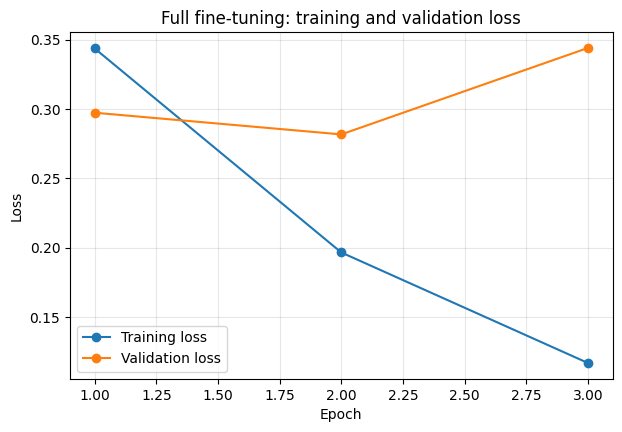

In [10]:
plot_loss_curves(full_log_history, "Full fine-tuning: training and validation loss")

In [11]:
full_val_metrics = full_trainer.evaluate(tokenized_datasets["validation"])
print("Full fine-tuning validation metrics:")
full_val_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.116921,0.344044,3,0.903000,0.894325,0.914000,0.904055


Full fine-tuning validation metrics:


{'eval_loss': 0.3440439999103546,
 'eval_accuracy': 0.903,
 'eval_precision': 0.8943248532289628,
 'eval_recall': 0.914,
 'eval_f1': 0.904055390702275}

In [12]:
full_test_metrics = evaluate_on_full_test(full_trainer, tokenized_datasets["test"])
print("Full fine-tuning metrics on the full IMDB test split:")
full_test_metrics

Full fine-tuning metrics on the full IMDB test split:


{'accuracy': 0.90368,
 'precision': 0.8986411755411597,
 'recall': 0.91,
 'f1': 0.904284919309961}

In [13]:
full_results = {
    "Model": "Full FT",
    "Trainable parameters": full_trainable_params,
    "Accuracy": full_test_metrics["accuracy"],
    "Precision": full_test_metrics["precision"],
    "Recall": full_test_metrics["recall"],
    "F1": full_test_metrics["f1"],
}

del full_trainer
del full_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

## 5. LoRA PEFT model

In [14]:
lora_hparams = pd.DataFrame([
    {"Hyperparameter": "Base model", "Value": BASE_MODEL},
    {"Hyperparameter": "Task type", "Value": "SEQ_CLS"},
    {"Hyperparameter": "Target modules", "Value": ", ".join(LORA_TARGET_MODULES)},
    {"Hyperparameter": "LoRA rank r", "Value": LORA_R},
    {"Hyperparameter": "LoRA alpha", "Value": LORA_ALPHA},
    {"Hyperparameter": "LoRA dropout", "Value": LORA_DROPOUT},
    {"Hyperparameter": "Learning rate", "Value": LORA_LR},
    {"Hyperparameter": "Train batch size", "Value": LORA_TRAIN_BATCH_SIZE},
    {"Hyperparameter": "Eval batch size", "Value": LORA_EVAL_BATCH_SIZE},
    {"Hyperparameter": "Number of epochs", "Value": LORA_EPOCHS},
    {"Hyperparameter": "Maximum sequence length", "Value": MAX_LENGTH},
    {"Hyperparameter": "Weight decay", "Value": LORA_WEIGHT_DECAY},
    {"Hyperparameter": "Gradient clipping", "Value": LORA_MAX_GRAD_NORM},
])
display(lora_hparams)

,Hyperparameter,Value
0,Base model,distilbert-base-uncased
1,Task type,SEQ_CLS
2,Target modules,"q_lin, v_lin"
3,LoRA rank r,8
4,LoRA alpha,16
5,LoRA dropout,0.1
6,Learning rate,0.0005
7,Train batch size,16
8,Eval batch size,64
9,Number of epochs,3


In [16]:
#%pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [17]:
set_seed(SEED)

lora_base_model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",

    modules_to_save=["pre_classifier", "classifier"],
)

lora_model = get_peft_model(lora_base_model, lora_config)

print("Trainable parameter summary from PEFT:")
lora_model.print_trainable_parameters()

lora_trainable_params, lora_total_params = count_parameters(lora_model)
print()
print(f"LoRA trainable parameters: {format_int(lora_trainable_params)}")
print(f"LoRA total parameters:     {format_int(lora_total_params)}")
print(f"Trainable percentage:      {100 * lora_trainable_params / lora_total_params:.4f}%")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameter summary from PEFT:
trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925

LoRA trainable parameters: 739,586
LoRA total parameters:     67,694,596
Trainable percentage:      1.0925%


In [18]:
trainable_names = [name for name, p in lora_model.named_parameters() if p.requires_grad]
for name in trainable_names[:40]:
    print(name)
if len(trainable_names) > 40:
    print(f"... {len(trainable_names) - 40} more trainable tensors")

base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_A.default.weight
base_model.model.distilbert.transformer.layer.0.attention.q_lin.lora_B.default.weight
base_model.model.distilbert.transformer.layer.0.attention.v_lin.lora_A.default.weight
base_model.model.distilbert.transformer.layer.0.attention.v_lin.lora_B.default.weight
base_model.model.distilbert.transformer.layer.1.attention.q_lin.lora_A.default.weight
base_model.model.distilbert.transformer.layer.1.attention.q_lin.lora_B.default.weight
base_model.model.distilbert.transformer.layer.1.attention.v_lin.lora_A.default.weight
base_model.model.distilbert.transformer.layer.1.attention.v_lin.lora_B.default.weight
base_model.model.distilbert.transformer.layer.2.attention.q_lin.lora_A.default.weight
base_model.model.distilbert.transformer.layer.2.attention.q_lin.lora_B.default.weight
base_model.model.distilbert.transformer.layer.2.attention.v_lin.lora_A.default.weight
base_model.model.distilbert.transformer.layer.2.attent

In [19]:
lora_args = make_training_args(
    output_dir="./distilbert_imdb_lora_peft",
    learning_rate=LORA_LR,
    per_device_train_batch_size=LORA_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=LORA_EVAL_BATCH_SIZE,
    num_train_epochs=LORA_EPOCHS,
    weight_decay=LORA_WEIGHT_DECAY,
    max_grad_norm=LORA_MAX_GRAD_NORM,
)

lora_trainer = make_trainer(
    model=lora_model,
    args=lora_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
)

lora_train_result = lora_trainer.train()
lora_log_history = lora_trainer.state.log_history.copy()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.337709,0.273931,0.883000,0.924612,0.834000,0.876972
2,0.261980,0.244726,0.901000,0.900200,0.902000,0.901099
3,0.214509,0.237093,0.903000,0.892788,0.916000,0.904245


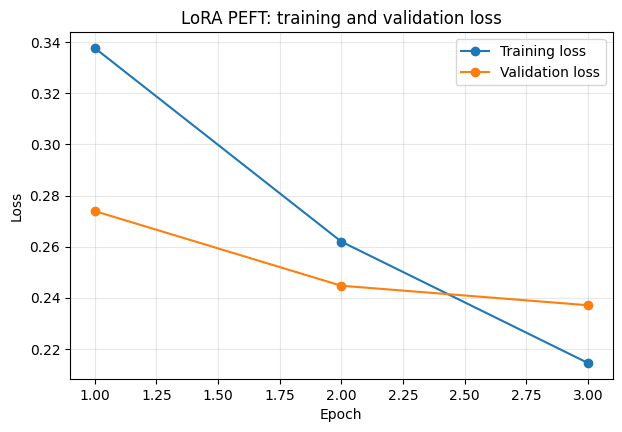

In [20]:
plot_loss_curves(lora_log_history, "LoRA PEFT: training and validation loss")

In [21]:
lora_val_metrics = lora_trainer.evaluate(tokenized_datasets["validation"])
print("LoRA validation metrics:")
lora_val_metrics

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.214509,0.237093,3,0.903000,0.892788,0.916000,0.904245


LoRA validation metrics:


{'eval_loss': 0.23709268867969513,
 'eval_accuracy': 0.903,
 'eval_precision': 0.8927875243664717,
 'eval_recall': 0.916,
 'eval_f1': 0.9042448173741362}

In [22]:
lora_test_metrics = evaluate_on_full_test(lora_trainer, tokenized_datasets["test"])
print("LoRA metrics on the full IMDB test split:")
lora_test_metrics

LoRA metrics on the full IMDB test split:


{'accuracy': 0.89916,
 'precision': 0.8930906799023084,
 'recall': 0.90688,
 'f1': 0.8999325209383559}

In [23]:
lora_results = {
    "Model": "LoRA",
    "Trainable parameters": lora_trainable_params,
    "Accuracy": lora_test_metrics["accuracy"],
    "Precision": lora_test_metrics["precision"],
    "Recall": lora_test_metrics["recall"],
    "F1": lora_test_metrics["f1"],
}

## 6. Test-set evaluation & comparison

In [24]:
comparison_df = pd.DataFrame([full_results, lora_results])

formatted_comparison_df = comparison_df.copy()
formatted_comparison_df["Trainable parameters"] = formatted_comparison_df["Trainable parameters"].map(lambda x: f"{x:,}")
for col in ["Accuracy", "Precision", "Recall", "F1"]:
    formatted_comparison_df[col] = formatted_comparison_df[col].map(lambda x: f"{x:.4f}")

display(formatted_comparison_df)

,Model,Trainable parameters,Accuracy,Precision,Recall,F1
0,Full FT,"66,955,010",0.9037,0.8986,0.9100,0.9043
1,LoRA,"739,586",0.8992,0.8931,0.9069,0.8999
